In [215]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [216]:
z = 34
i = 250
j = 500

w = xr.load_dataset("/Users/jvalenti/Downloads/ubcSSg3DwGridFields1hV21-11_144c_21d8_6101.nc").wVelocity.isel(depth=z,gridY=0, gridX=0)
ssh = xr.load_dataset("/Users/jvalenti/Downloads/ubcSSgSeaSurfaceHeightField1hV21-11_5c5e_51fe_19b0.nc").ssh.isel(gridY=j, gridX=i)
mask = xr.load_dataset("/Users/jvalenti/MOAD/grid2/mesh_mask202311_TD.nc").isel(z=z,y=j, x=i,t=0)

In [217]:
e3t_0 =mask.e3t_0
totaldepth = mask.totaldepth

In [218]:
dssh_dt = np.gradient(ssh, 3600, axis=0)
wvvl = -(dssh_dt*w.depth.values)/(ssh+totaldepth)

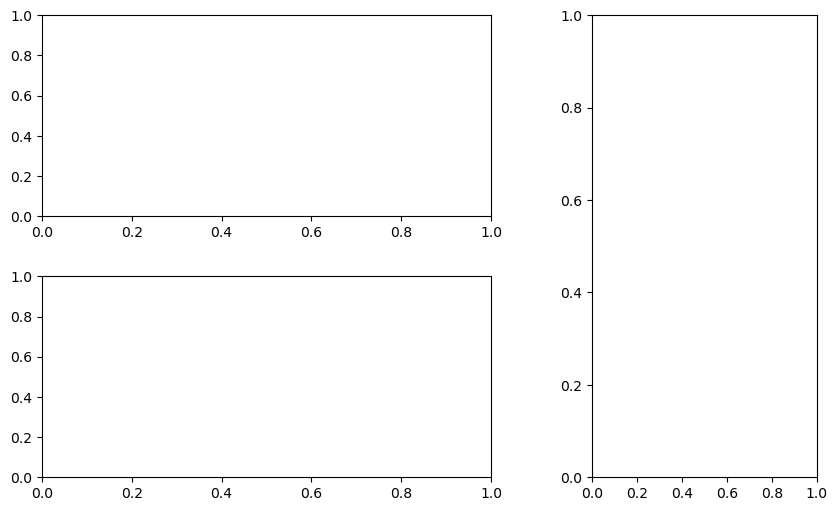

In [219]:
fig = plt.figure(figsize=(10, 6))

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[1, 0.5],   # right panel slightly wider; adjust as needed
    height_ratios=[1, 1],
    wspace=0.3,
    hspace=0.3
)

axs1 = fig.add_subplot(gs[0, 0])   # top-left
axs2 = fig.add_subplot(gs[1, 0])   # bottom-left
axs3 = fig.add_subplot(gs[:, 1])   # right panel spans both rows

In [220]:
axs1.plot(dssh_dt,label="dSSH/dt")
axs1.plot(w,label="w",c='tab:orange')
axs1.plot(wvvl,label=r"$w_{VVL}$",c='tab:green')
axs1.set_ylabel("[m/s]")
axs1.set_xlabel("Time (hours)")
axs1.legend()

axs2.plot(wvvl,c='tab:green')
axs2.plot(w,label="w",c='tab:orange')
axs2.set_ylabel("[m/s]")
axs2.set_xlabel("Time (hours)")

Text(0.5, 4.444444444444452, 'Time (hours)')

In [221]:
w = xr.load_dataset("/Users/jvalenti/Downloads/ubcSSg3DwGridFields1hV21-11_144c_21d8_6101.nc").wVelocity.isel(depth=slice(0,-1),gridY=0, gridX=0,time=3)
mask = xr.load_dataset("/Users/jvalenti/MOAD/grid2/mesh_mask202311_TD.nc").isel(z=slice(0,-1),y=j, x=i,t=0)

In [222]:
wvvl = -(dssh_dt[3]*w.depth.values)/(ssh[3]+totaldepth).values

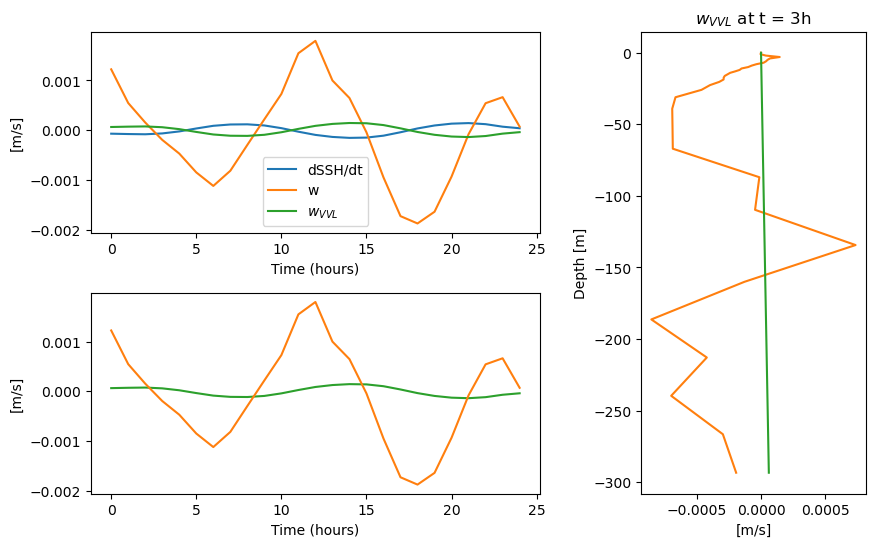

In [223]:
axs3.plot(w[:z+1],-w.depth[:z+1],c='tab:orange',label="w")
axs3.plot(wvvl[:z+1],-w.depth[:z+1],c='tab:green',label=r"$w_{VVL}$")
axs3.set_xlabel("[m/s]")
axs3.set_ylabel("Depth [m]")
axs3.xaxis.set_major_locator(MaxNLocator(nbins=4))
axs3.set_title(r'$w_{VVL}$ at t = 3h')
fig

/Users/jvalenti/MOAD/analysis-jose/.pixi/envs/shem/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in divide
  result_data = func(*input_data)


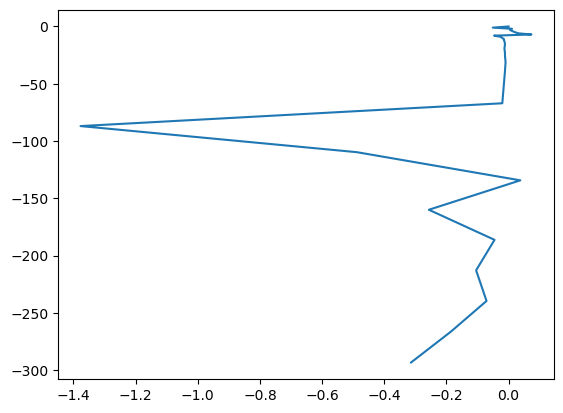

In [225]:
plt.plot(wvvl/w,-w.depth)
